In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

C:\Users\hp\logistics_shipment_data_cleaned.csv


## Import libraries

## Load the cleaned dataset

In [2]:
df = pd.read_csv("logistics_shipment_data_cleaned.csv")

In [4]:
df.head()

,Shipment_ID,Origin_Warehouse,Destination,Carrier,Shipment_Date,Delivery_Date,Weight_kg,Cost,Status,Distance_miles,Transit_Days,Invalid_Date
0,SH10001,Mumbai_Warehouse,Hyderabad,DHL,2025-02-02,2025-02-08,8.1,979.63,Delivered,2202,6,False
1,SH10002,Delhi_Warehouse,Kolkata,Delhivery,2025-10-10,2025-10-14,6.9,186.22,Delivered,202,4,False
2,SH10003,Bengaluru_Warehouse,Ahmedabad,BlueDart,2025-08-27,2025-08-30,11.6,685.09,Delivered,1024,3,False
3,SH10004,Delhi_Warehouse,Kolkata,DHL,2025-06-10,2025-06-14,11.1,646.05,Delivered,1173,4,False
4,SH10005,Hyderabad_Warehouse,Delhi,Delhivery,2025-06-08,2025-06-14,15.1,1044.77,Delivered,2005,6,False


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2000
Number of columns: 12


## Dataset information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Shipment_ID       2000 non-null   object 
 1   Origin_Warehouse  2000 non-null   object 
 2   Destination       2000 non-null   object 
 3   Carrier           2000 non-null   object 
 4   Shipment_Date     2000 non-null   object 
 5   Delivery_Date     2000 non-null   object 
 6   Weight_kg         2000 non-null   float64
 7   Cost              2000 non-null   float64
 8   Status            2000 non-null   object 
 9   Distance_miles    2000 non-null   int64  
 10  Transit_Days      2000 non-null   int64  
 11  Invalid_Date      2000 non-null   bool   
dtypes: bool(1), float64(2), int64(2), object(7)
memory usage: 174.0+ KB


## Check missing values

In [7]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Shipment_ID         0
Origin_Warehouse    0
Destination         0
Carrier             0
Shipment_Date       0
Delivery_Date       0
Weight_kg           0
Cost                0
Status              0
Distance_miles      0
Transit_Days        0
Invalid_Date        0
dtype: int64


## Check duplicates

In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


# Part A — Descriptive Statistics

## Numerical summary

In [9]:
df.describe()

,Weight_kg,Cost,Distance_miles,Transit_Days
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,23.170900,807.194580,1280.772500,4.233000
std,43.128261,371.799351,704.469105,1.693855
min,1.300000,63.810000,51.000000,1.000000
25%,11.200000,537.977500,652.000000,3.000000
50%,18.500000,794.255000,1262.500000,4.000000
75%,27.500000,1055.302500,1891.000000,6.000000
max,1200.000000,6500.000000,2499.000000,9.000000


## Median values

In [10]:
numeric_columns = df.select_dtypes(include=np.number).columns

median_values = df[numeric_columns].median()

print("Median values:")
print(median_values)

Median values:
Weight_kg           18.500
Cost               794.255
Distance_miles    1262.500
Transit_Days         4.000
dtype: float64


## Mean values

In [11]:
mean_values = df[numeric_columns].mean()

print("Mean values:")
print(mean_values)

Mean values:
Weight_kg           23.17090
Cost               807.19458
Distance_miles    1280.77250
Transit_Days         4.23300
dtype: float64


## Standard deviation

In [12]:
std_values = df[numeric_columns].std()

print("Standard deviation:")
print(std_values)

Standard deviation:
Weight_kg          43.128261
Cost              371.799351
Distance_miles    704.469105
Transit_Days        1.693855
dtype: float64


# Part B — Categorical Analysis

## Check categorical columns

In [13]:
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical columns:")
print(list(categorical_columns))

Categorical columns:
['Shipment_ID', 'Origin_Warehouse', 'Destination', 'Carrier', 'Shipment_Date', 'Delivery_Date', 'Status']


## Shipment status

In [14]:
print(df["Status"].value_counts())

Status
Delivered     1551
Delayed        292
In Transit     157
Name: count, dtype: int64


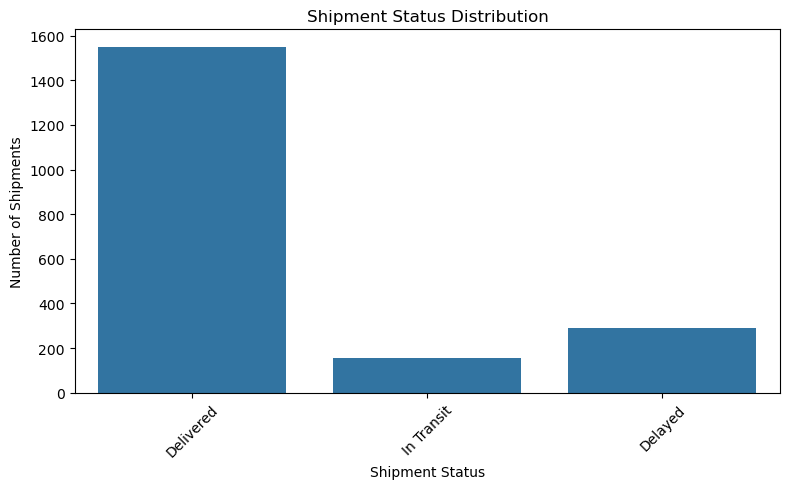

In [15]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Status")

plt.title("Shipment Status Distribution")
plt.xlabel("Shipment Status")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Interpretation

This visualization shows how shipments are distributed across different delivery statuses and helps identify whether delayed or problematic shipments represent a significant portion of total shipments.

# Part C — Shipment Distribution

## Shipment weight distribution

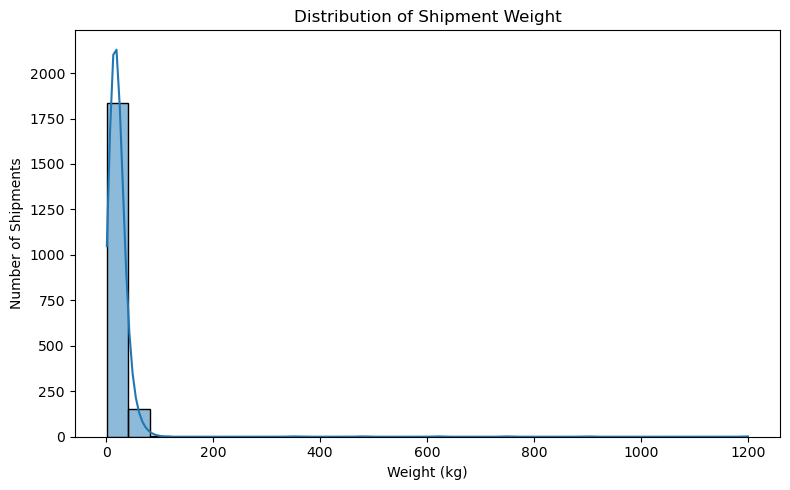

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Weight_kg", bins=30, kde=True)

plt.title("Distribution of Shipment Weight")
plt.xlabel("Weight (kg)")
plt.ylabel("Number of Shipments")

plt.tight_layout()
plt.show()

## Transportation cost distribution

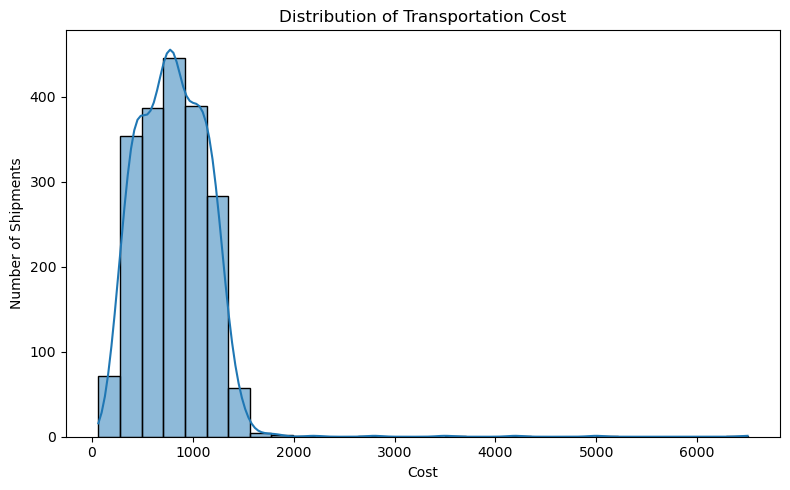

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Cost", bins=30, kde=True)

plt.title("Distribution of Transportation Cost")
plt.xlabel("Cost")
plt.ylabel("Number of Shipments")

plt.tight_layout()
plt.show()

## Distance distribution

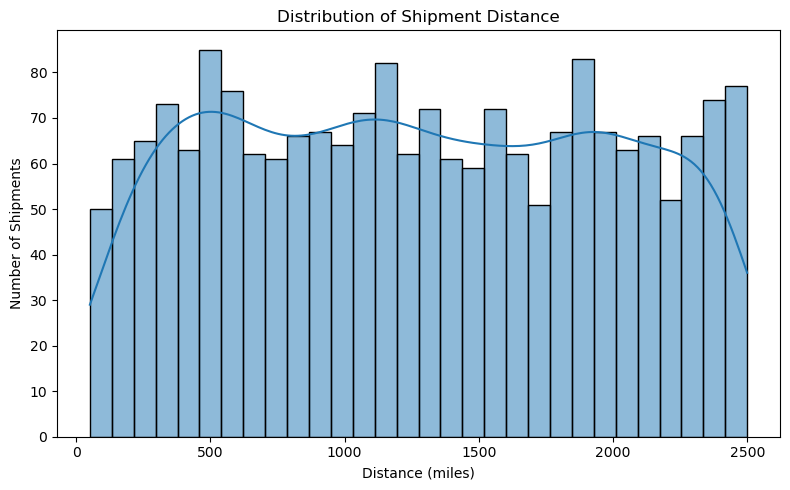

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Distance_miles", bins=30, kde=True)

plt.title("Distribution of Shipment Distance")
plt.xlabel("Distance (miles)")
plt.ylabel("Number of Shipments")

plt.tight_layout()
plt.show()

## Transit time distribution

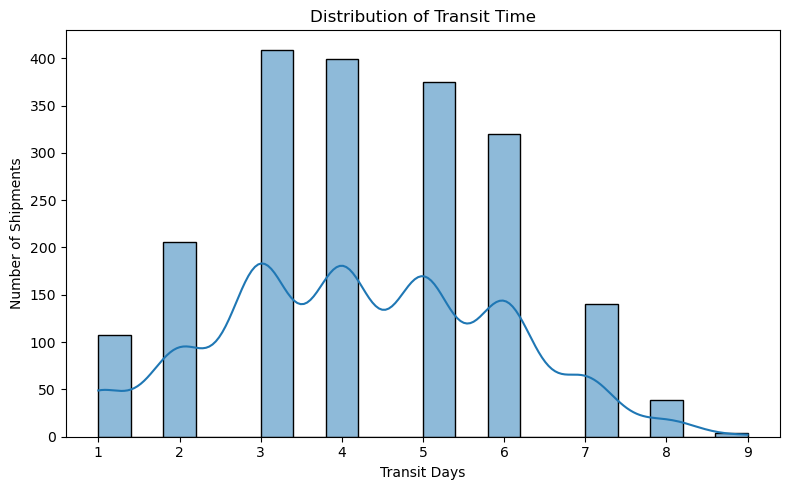

In [19]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Transit_Days", bins=20, kde=True)

plt.title("Distribution of Transit Time")
plt.xlabel("Transit Days")
plt.ylabel("Number of Shipments")

plt.tight_layout()
plt.show()

# Part D — Correlation Analysis

## Correlation matrix

In [20]:
correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,Weight_kg,Cost,Distance_miles,Transit_Days
Weight_kg,1.000000,0.090762,-0.018810,-0.027167
Cost,0.090762,1.000000,0.796603,0.649613
Distance_miles,-0.018810,0.796603,1.000000,0.824445
Transit_Days,-0.027167,0.649613,0.824445,1.000000


## Correlation heatmap

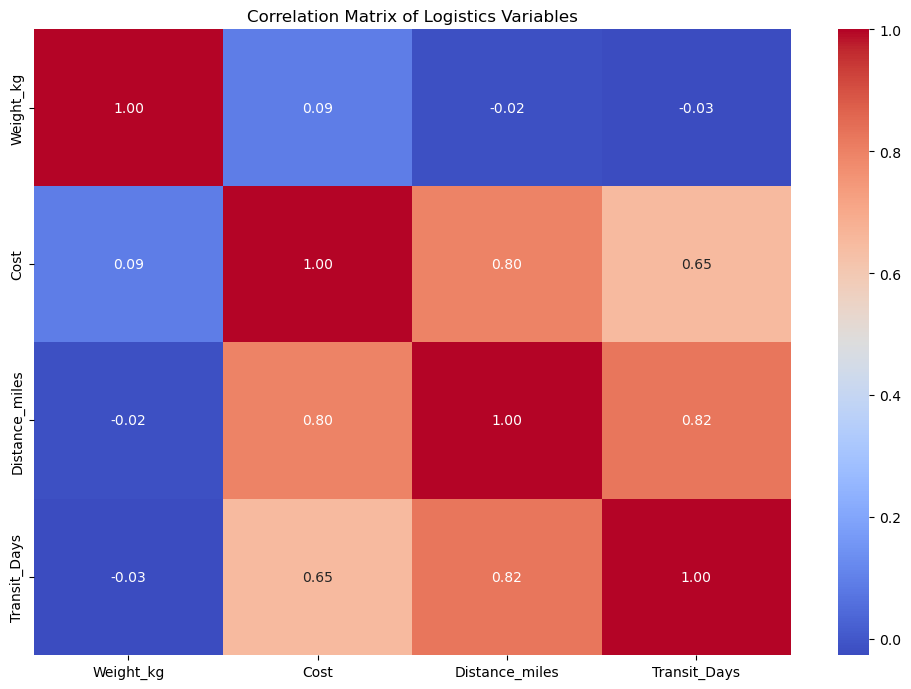

In [21]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Logistics Variables")

plt.tight_layout()
plt.show()

# Part E — Cost Drivers

## Cost vs Distance

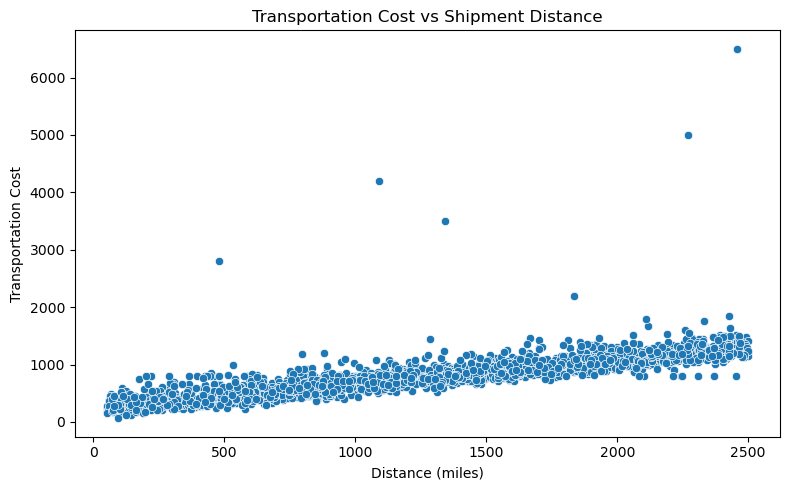

In [22]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Distance_miles",
    y="Cost"
)

plt.title("Transportation Cost vs Shipment Distance")
plt.xlabel("Distance (miles)")
plt.ylabel("Transportation Cost")

plt.tight_layout()
plt.show()

## Cost vs Weight

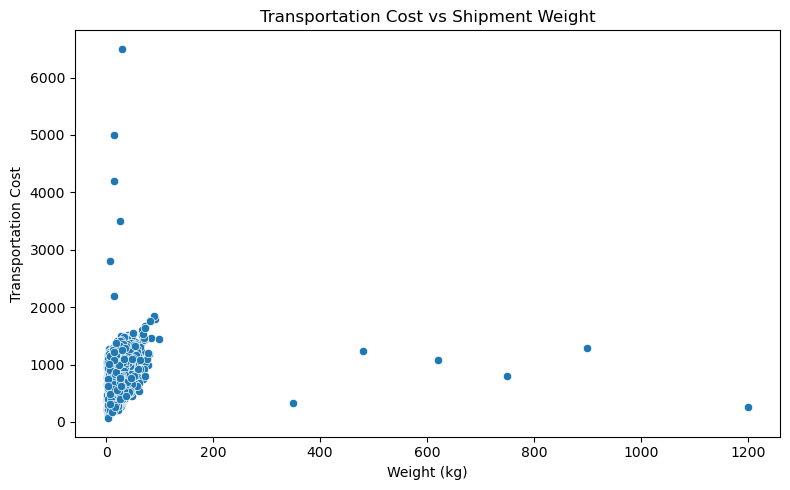

In [23]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Weight_kg",
    y="Cost"
)

plt.title("Transportation Cost vs Shipment Weight")
plt.xlabel("Weight (kg)")
plt.ylabel("Transportation Cost")

plt.tight_layout()
plt.show()

## Part F — Transit Performance


## Distance vs Transit Days

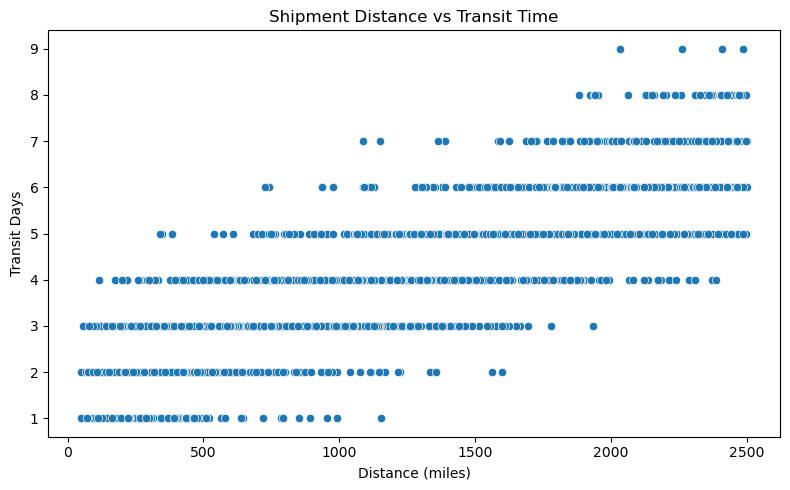

In [24]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Distance_miles",
    y="Transit_Days"
)

plt.title("Shipment Distance vs Transit Time")
plt.xlabel("Distance (miles)")
plt.ylabel("Transit Days")

plt.tight_layout()
plt.show()

# Part G — Carrier Analysis

## Shipments by carrier

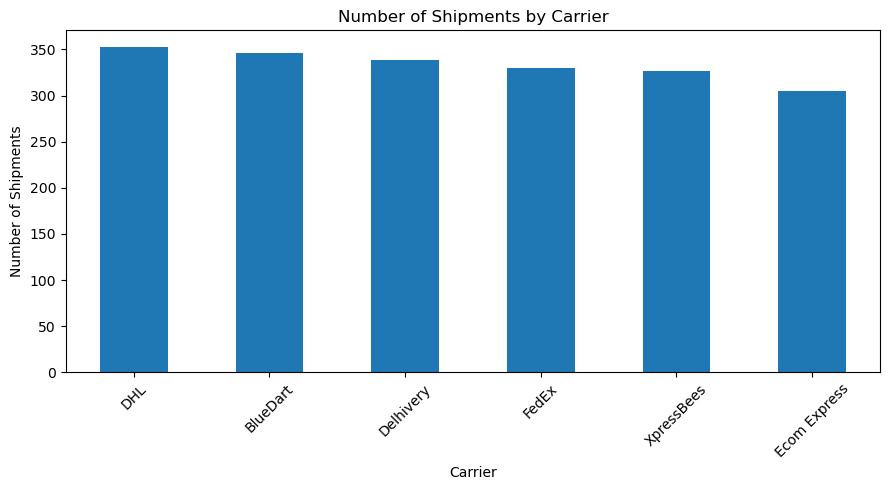

In [25]:
carrier_counts = df["Carrier"].value_counts()

plt.figure(figsize=(9, 5))

carrier_counts.plot(kind="bar")

plt.title("Number of Shipments by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Average cost by carrier

In [26]:
carrier_cost = (
    df.groupby("Carrier")["Cost"]
    .mean()
    .sort_values(ascending=False)
)

print(carrier_cost)

Carrier
BlueDart        828.612702
FedEx           816.149348
Delhivery       812.764838
Ecom Express    802.359098
XpressBees      792.809572
DHL             789.983980
Name: Cost, dtype: float64


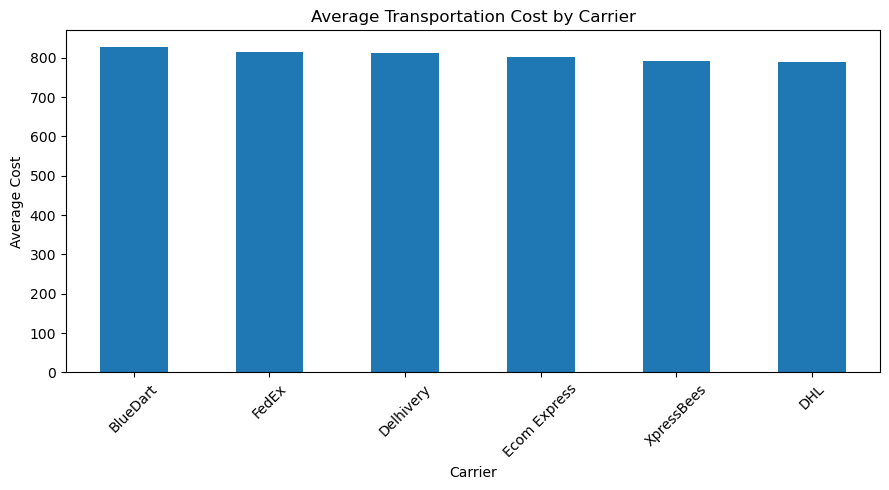

In [27]:
plt.figure(figsize=(9, 5))

carrier_cost.plot(kind="bar")

plt.title("Average Transportation Cost by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Average Cost")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Warehouse Analysis

## Shipments by warehouse

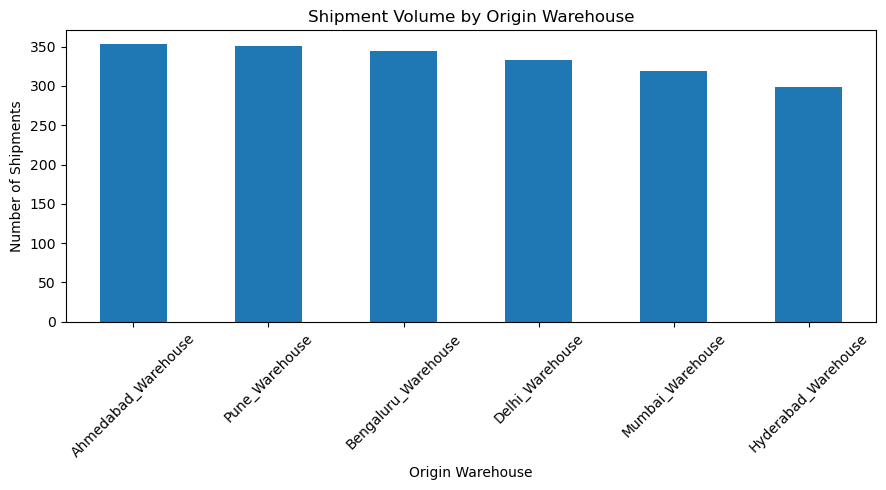

In [32]:
warehouse_counts = df["Origin_Warehouse"].value_counts()

plt.figure(figsize=(9, 5))

warehouse_counts.plot(kind="bar")

plt.title("Shipment Volume by Origin Warehouse")
plt.xlabel("Origin Warehouse")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Part I — Destination Analysis

## Top destinations

In [33]:
destination_counts = df["Destination"].value_counts()

print(destination_counts.head(10))

Destination
Kolkata      192
Jaipur       192
Chennai      181
Nashik       175
Surat        174
Hyderabad    169
Nagpur       164
Pune         160
Delhi        152
Mumbai       149
Name: count, dtype: int64


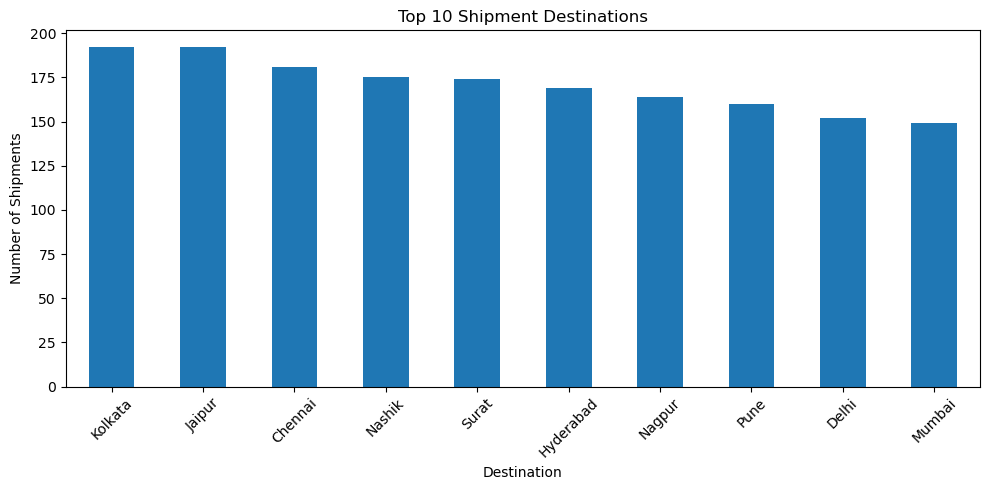

In [34]:
plt.figure(figsize=(10, 5))

destination_counts.head(10).plot(kind="bar")

plt.title("Top 10 Shipment Destinations")
plt.xlabel("Destination")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Part J — Key Logistics Metrics

## Calculate important KPIs

In [35]:
print("Average shipment weight:", df["Weight_kg"].mean())
print("Average transportation cost:", df["Cost"].mean())
print("Average shipment distance:", df["Distance_miles"].mean())
print("Average transit time:", df["Transit_Days"].mean())

print("Median shipment weight:", df["Weight_kg"].median())
print("Median transportation cost:", df["Cost"].median())
print("Median shipment distance:", df["Distance_miles"].median())
print("Median transit time:", df["Transit_Days"].median())

Average shipment weight: 23.170900000000003
Average transportation cost: 807.1945800000001
Average shipment distance: 1280.7725
Average transit time: 4.233
Median shipment weight: 18.5
Median transportation cost: 794.255
Median shipment distance: 1262.5
Median transit time: 4.0


# Part K — Create a KPI summary table

In [36]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Average Weight (kg)",
        "Average Cost",
        "Average Distance (miles)",
        "Average Transit Days",
        "Median Weight (kg)",
        "Median Cost",
        "Median Distance (miles)",
        "Median Transit Days"
    ],
    "Value": [
        df["Weight_kg"].mean(),
        df["Cost"].mean(),
        df["Distance_miles"].mean(),
        df["Transit_Days"].mean(),
        df["Weight_kg"].median(),
        df["Cost"].median(),
        df["Distance_miles"].median(),
        df["Transit_Days"].median()
    ]
})

kpi_summary

,Metric,Value
0,Average Weight (kg),23.17090
1,Average Cost,807.19458
2,Average Distance (miles),1280.77250
3,Average Transit Days,4.23300
4,Median Weight (kg),18.50000
5,Median Cost,794.25500
6,Median Distance (miles),1262.50000
7,Median Transit Days,4.00000


# Part L — Final analytical summary

In [38]:
print("WEEK 3 LOGISTICS ANALYSIS SUMMARY")
print("=" * 50)

print(f"Total shipments: {len(df):,}")
print(f"Average shipment weight: {df['Weight_kg'].mean():.2f} kg")
print(f"Average transportation cost: {df['Cost'].mean():.2f}")
print(f"Average distance: {df['Distance_miles'].mean():.2f} miles")
print(f"Average transit time: {df['Transit_Days'].mean():.2f} days")

print("\nTop carrier:")
print(df["Carrier"].value_counts().idxmax())

print("\nTop origin warehouse:")
print(df["Origin_Warehouse"].value_counts().idxmax())

print("\nTop destination:")
print(df["Destination"].value_counts().idxmax())

WEEK 3 LOGISTICS ANALYSIS SUMMARY
Total shipments: 2,000
Average shipment weight: 23.17 kg
Average transportation cost: 807.19
Average distance: 1280.77 miles
Average transit time: 4.23 days

Top carrier:
DHL

Top origin warehouse:
Ahmedabad_Warehouse

Top destination:
Kolkata


In [39]:
df.describe(include="all")

,Shipment_ID,Origin_Warehouse,Destination,Carrier,Shipment_Date,Delivery_Date,Weight_kg,Cost,Status,Distance_miles,Transit_Days,Invalid_Date
count,2000,2000,2000,2000,2000,2000,2000.000000,2000.000000,2000,2000.000000,2000.000000,2000
unique,2000,6,12,6,364,364,NaN,NaN,3,NaN,NaN,1
top,SH11984,Ahmedabad_Warehouse,Kolkata,DHL,2025-03-02,2025-07-28,NaN,NaN,Delivered,NaN,NaN,False
freq,1,353,192,353,12,13,NaN,NaN,1551,NaN,NaN,2000
mean,NaN,NaN,NaN,NaN,NaN,NaN,23.170900,807.194580,NaN,1280.772500,4.233000,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,43.128261,371.799351,NaN,704.469105,1.693855,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1.300000,63.810000,NaN,51.000000,1.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,11.200000,537.977500,NaN,652.000000,3.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,18.500000,794.255000,NaN,1262.500000,4.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,27.500000,1055.302500,NaN,1891.000000,6.000000,NaN


In [40]:
df["Invalid_Date"].value_counts(dropna=False)

Invalid_Date
False    2000
Name: count, dtype: int64

In [41]:
avg_transit_carrier = (
    df.groupby("Carrier")["Transit_Days"]
    .mean()
    .sort_values(ascending=False)
)

print("Average transit time by carrier:")
print(avg_transit_carrier)

Average transit time by carrier:
Carrier
BlueDart        4.369942
Ecom Express    4.275410
FedEx           4.227273
DHL             4.198300
Delhivery       4.171091
XpressBees      4.155963
Name: Transit_Days, dtype: float64


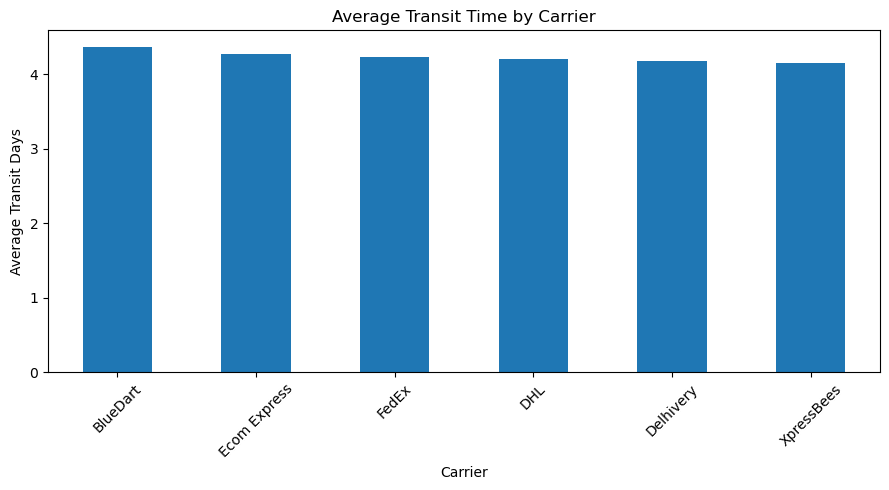

In [42]:
plt.figure(figsize=(9, 5))

avg_transit_carrier.plot(kind="bar")

plt.title("Average Transit Time by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Average Transit Days")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()